# Aerial Photogrammetry 3D — Phase 1: Synthetic Scene & Data Generation

---

## What is Aerial Photogrammetry?

**Photogrammetry** is the science of recovering 3-D geometry from 2-D photographs.  
When the photographs are taken from above — by a drone, aircraft, or satellite — the problem is called **aerial photogrammetry**.

The goal: given a set of overlapping aerial images of a scene, automatically reconstruct a **dense 3-D model** (point cloud → mesh → textured model) that is metrically accurate enough to measure distances, volumes, and elevations.

**Real-world applications:**
- Urban planning & building-height surveys
- Precision agriculture (crop-health mapping, field volume)
- Disaster assessment (before/after change detection)
- Archaeological site documentation
- Autonomous vehicle map creation

---

## The 8-Phase Pipeline We Will Build

```
Phase 1 ─ Data Generation          (YOU ARE HERE)
           │  Synthetic urban scene + aerial camera rig
           │  → RGB images, GT depth maps, GT poses
           ▼
Phase 2 ─ Feature Detection & Matching
           │  SIFT keypoints, descriptor matching across image pairs
           ▼
Phase 3 ─ Structure from Motion (SfM)
           │  Recover camera poses + sparse 3-D point cloud
           ▼
Phase 4 ─ Multi-View Stereo (MVS)
           │  Dense depth estimation per image → dense point cloud
           ▼
Phase 5 ─ Mesh Reconstruction
           │  Poisson surface reconstruction from dense cloud
           ▼
Phase 6 ─ Texture Mapping
           │  Project images onto mesh → UV atlas
           ▼
Phase 7 ─ Occlusion Inpainting
           │  Fill unseen regions of the texture atlas
           ▼
Phase 8 ─ Evaluation
           │  Reprojection error, Chamfer distance vs. GT
```

Each notebook covers one phase.  By the end you will have run a complete photogrammetry pipeline from first principles.

---

## Why Synthetic Data for Learning?

In a real deployment you would fly a drone and collect raw imagery.  
For **learning and debugging**, synthetic data has three decisive advantages:

| Property | Real drone data | Synthetic data |
|---|---|---|
| **Ground truth poses** | GPS/IMU only (noisy) | Exact, by construction |
| **Ground truth depth** | LiDAR (expensive) | Exact per-pixel, free |
| **Ground truth geometry** | Unknown | Known 3-D mesh |
| **Reproducibility** | Re-fly required | `seed=42` |
| **Cost** | Flight time + equipment | Zero |

Having exact ground truth lets us **measure** how well each algorithm works, which is the only way to understand where the pipeline fails and why.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import open3d as o3d
import cv2
import matplotlib.pyplot as plt
import json
%matplotlib inline

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


---

## Step 1 — Build the Synthetic Urban Scene

We create a procedural **100 × 100 m urban block**:

```
 Z
 │      ┌──┐  ┌────┐
 │  ┌─┐ │  │  │    │   ← buildings (5–30 m tall)
 │  │ │ │  │  │    │
 └──┴─┴─┴──┴──┴────┴──── Y
 ────────────────────── ground plane (100×100 m)
```

The scene is a single `open3d.geometry.TriangleMesh` — the same data structure a real LiDAR or photogrammetry pipeline would produce.  Everything is **axis-aligned boxes** (boxes are the simplest testbed: well-defined faces, clear silhouettes, predictable normals).

**Design choices:**
- 100 × 100 m → large enough to require multiple camera positions for full coverage
- 15 buildings → enough occlusion and depth variation to stress-test the pipeline
- Heights 5–30 m → same height range as real urban blocks

In [2]:
from src.data_gen.synthetic_scene import build_scene, get_scene_bounds

scene = build_scene(n_buildings=15, seed=42)
min_b, max_b = get_scene_bounds()

print(f"Vertices : {len(scene.vertices):,}")
print(f"Triangles: {len(scene.triangles):,}")
print(f"Bounds   : {min_b} → {max_b} m")
print()
print("Each box contributes 8 vertices and 12 triangles (6 faces × 2 tris/face).")
print(f"Expected: ~{16 * 8} vertices, ~{16 * 12} triangles for 15 buildings + 1 ground")

Vertices : 128
Triangles: 192
Bounds   : [0. 0. 0.] → [100. 100.  35.] m

Each box contributes 8 vertices and 12 triangles (6 faces × 2 tris/face).
Expected: ~128 vertices, ~192 triangles for 15 buildings + 1 ground


---

## Step 2 — The Pinhole Camera Model

Before we place cameras, we need to understand the model.

Every camera in this pipeline is described by two things:

### Intrinsic matrix K  (optics — same for all cameras)

$$K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

- $f_x, f_y$: focal length in **pixels** — controls zoom / field of view
- $c_x, c_y$: **principal point** — where the optical axis hits the image (usually image center)
- We use FOV = 60°, which gives $f = \frac{W/2}{\tan(30°)} \approx 693$ px for an 800 px wide image

### Extrinsic matrix [R | t]  (pose — different per camera)

$$\mathbf{x}_{cam} = R \, \mathbf{X}_{world} + \mathbf{t}$$

- $R$ (3×3 rotation): which way the camera is pointing
- $\mathbf{t}$ (3-vector): camera position encoded as $\mathbf{t} = -R\,\mathbf{e}$ where $\mathbf{e}$ is the camera centre in world coordinates

### Projection  (3-D → 2-D)

$$\begin{bmatrix} u \\ v \end{bmatrix} = \begin{bmatrix} f_x \, X_{cam} / Z_{cam} + c_x \\ f_y \, Y_{cam} / Z_{cam} + c_y \end{bmatrix}$$

This is a **perspective projection**: objects further away (larger $Z$) appear smaller on the image.  All photogrammetry builds on inverting this mapping.

---

## Step 3 — Design the Camera Rig

A single camera cannot see all of a scene.  We need **overlapping views** so that the same 3-D point appears in at least 2–3 images (required for triangulation in SfM).

**Grid layout:** 4 × 4 = 16 cameras evenly spaced over the scene at 50 m altitude.

```
Top-down view (X-Y plane):

  Y=80  ●   ●   ●   ●
        │   │   │   │    ← look-at lines (toward ground)
  Y=60  ●   ●   ●   ●
        │   │   │   │
  Y=40  ●   ●   ●   ●
        │   │   │   │
  Y=20  ●   ●   ●   ●
       X=20 40  60  80
```

**Why 10° nadir tilt?** A perfectly nadir (straight-down) camera captures rooftops well but sees no façades — the vertical walls of buildings become razor-thin in the image and produce no matchable features.  A small tilt exposes façade texture while keeping full roof coverage.

**Why 50 m altitude?** At 50 m with a 60° FOV, each image covers roughly 58 × 43 m on the ground.  Adjacent images (spaced 20 m apart) share ~65% overlap — the minimum for reliable feature matching.

In [3]:
from src.data_gen.camera_rig import generate_camera_poses

poses = generate_camera_poses(grid_size=4, altitude=50.0, tilt_deg=10.0)
K = np.array(poses[0]['K'])

print(f"Number of cameras : {len(poses)}")
print(f"\nIntrinsic matrix K (shared by all cameras):")
print(K.astype(int))
print(f"\nFocal length: {K[0,0]:.1f} px  →  FOV ≈ {2*np.degrees(np.arctan(400/K[0,0])):.1f}°")
print(f"\nCamera 0:")
print(f"  position (eye): {poses[0]['eye']}")
print(f"  R (world→cam rotation):\n{np.array(poses[0]['R'])}")

Number of cameras : 16

Intrinsic matrix K (shared by all cameras):
[[692   0 400]
 [  0 692 300]
 [  0   0   1]]

Focal length: 692.8 px  →  FOV ≈ 60.0°

Camera 0:
  position (eye): [20.0, 20.0, 50.0]
  R (world→cam rotation):
[[ 1.          0.         -0.        ]
 [ 0.          0.98525577  0.17108787]
 [ 0.         -0.17108787  0.98525577]]


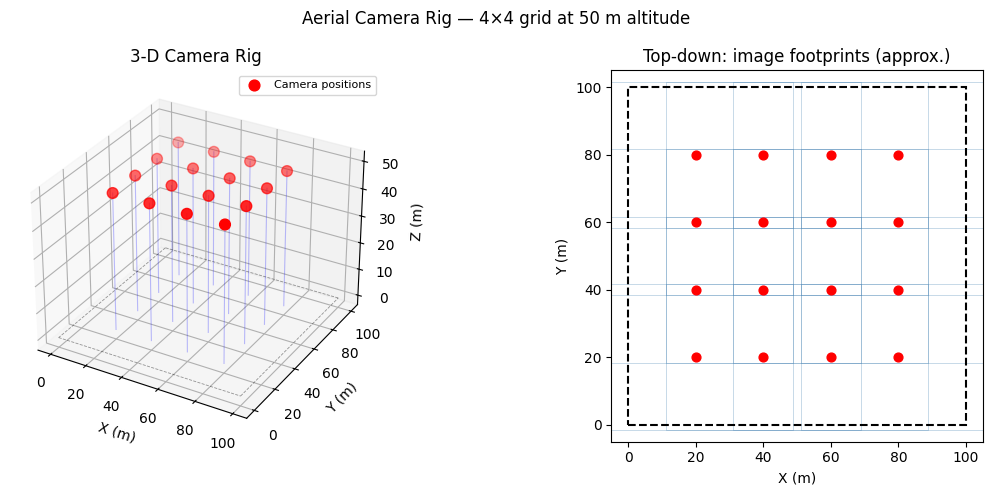

Approx. footprint per image: 58 × 43 m
Camera spacing: 20 m  →  overlap ≈ 65%


In [4]:
eyes    = np.array([p['eye']    for p in poses])
targets = np.array([p['eye']    for p in poses])  # approximate ground targets

fig = plt.figure(figsize=(12, 5))

# ── 3-D view ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(121, projection='3d')
ax3.scatter(eyes[:,0], eyes[:,1], eyes[:,2], c='red', s=60, label='Camera positions')
for p in poses:
    e = np.array(p['eye'])
    g = e.copy(); g[2] = 0.0
    ax3.plot([e[0], g[0]], [e[1], g[1]], [e[2], g[2]], 'b-', alpha=0.25, lw=0.8)
# Draw scene boundary
for xs, ys in [([0,100],[0,0]), ([100,100],[0,100]),
               ([100,0],[100,100]), ([0,0],[100,0])]:
    ax3.plot(xs, ys, [0,0], 'k--', lw=0.6, alpha=0.4)
ax3.set_xlabel('X (m)'); ax3.set_ylabel('Y (m)'); ax3.set_zlabel('Z (m)')
ax3.set_title('3-D Camera Rig')
ax3.legend(fontsize=8)

# ── Top-down view (coverage estimation) ───────────────────────────
ax2 = fig.add_subplot(122)
ax2.set_xlim(-5, 105); ax2.set_ylim(-5, 105)
ax2.set_aspect('equal')

# Rough footprint per camera: ±half_w in X, ±half_h in Y at 50 m
half_w = 50 * np.tan(np.radians(30))   # ~29 m
half_h = half_w * (600 / 800)           # ~22 m
for p in poses:
    cx, cy = p['eye'][0], p['eye'][1]
    rect = plt.Rectangle((cx-half_w, cy-half_h), 2*half_w, 2*half_h,
                          fill=False, edgecolor='steelblue', alpha=0.3, lw=0.7)
    ax2.add_patch(rect)
ax2.scatter(eyes[:,0], eyes[:,1], c='red', s=40, zorder=5)
ax2.add_patch(plt.Rectangle((0,0), 100, 100, fill=False, edgecolor='k', lw=1.5, ls='--'))
ax2.set_xlabel('X (m)'); ax2.set_ylabel('Y (m)')
ax2.set_title('Top-down: image footprints (approx.)')

plt.suptitle('Aerial Camera Rig — 4×4 grid at 50 m altitude', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Approx. footprint per image: {2*half_w:.0f} × {2*half_h:.0f} m")
print(f"Camera spacing: {(80-20)/3:.0f} m  →  overlap ≈ {100*(1 - 20/(2*half_w)):.0f}%")

---

## Step 4 — Render: 3-D Scene → 2-D Images + Depth Maps

We now project the 3-D mesh through each camera to produce:

1. **Color image** (800 × 600 RGB) — what a real drone camera would capture
2. **Depth map** (800 × 600 float32) — the Z-distance in metres for each pixel

The renderer is a **software Z-buffer rasterizer** (no GPU or display server required).  
For each triangle it:
1. Projects the 3 vertices to pixel space using K and [R|t]
2. Finds all pixels inside the triangle (edge functions)
3. Interpolates depth and vertex color using barycentric coordinates
4. Applies a Z-buffer test to handle occlusion (closer triangle wins)

**Why does depth matter?**  
In a real pipeline you would *not* have ground-truth depth — you'd have to estimate it (Phase 4, MVS).  Having exact GT depth lets us:
- Measure how close our MVS estimates are
- Fuse depth maps into a point cloud with known error bounds
- Debug Phase 3 (SfM) by comparing estimated poses to GT poses

In [5]:
from src.data_gen.camera_rig import render_scene

synth_dir = os.path.join('..', 'data', 'synthetic')
os.makedirs(synth_dir, exist_ok=True)

img_dir, depth_dir, poses_path = render_scene(scene, poses, synth_dir)
print(f"Images saved  → {img_dir}")
print(f"Depths saved  → {depth_dir}")
print(f"Poses saved   → {poses_path}")

[data_gen] Rendered 16 images → ..\data\synthetic\images
Images saved  → ..\data\synthetic\images
Depths saved  → ..\data\synthetic\GT_depth
Poses saved   → ..\data\synthetic\GT_poses.json


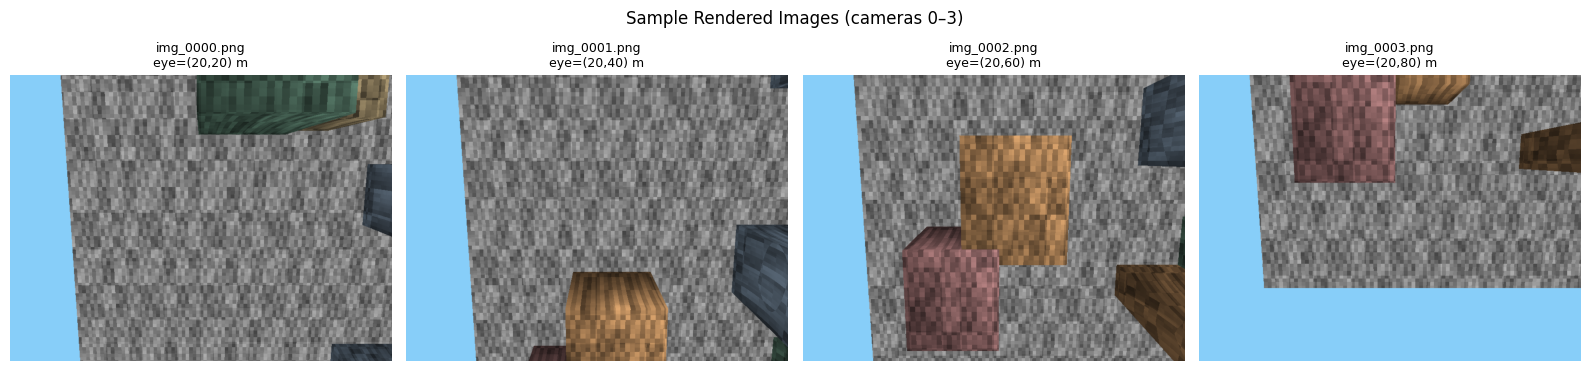

Notice: buildings appear at different positions as the camera moves across the grid.
The overlap between adjacent frames is what makes feature matching (Phase 2) possible.


In [6]:
img_files = sorted(os.listdir(img_dir))[:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, fname in zip(axes, img_files):
    img = cv2.imread(os.path.join(img_dir, fname))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    cam_idx = int(fname.split('_')[1].split('.')[0])
    eye = poses[cam_idx]['eye']
    ax.set_title(f"{fname}\neye=({eye[0]:.0f},{eye[1]:.0f}) m", fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Rendered Images (cameras 0–3)', fontsize=12)
plt.tight_layout()
plt.show()

print("Notice: buildings appear at different positions as the camera moves across the grid.")
print("The overlap between adjacent frames is what makes feature matching (Phase 2) possible.")

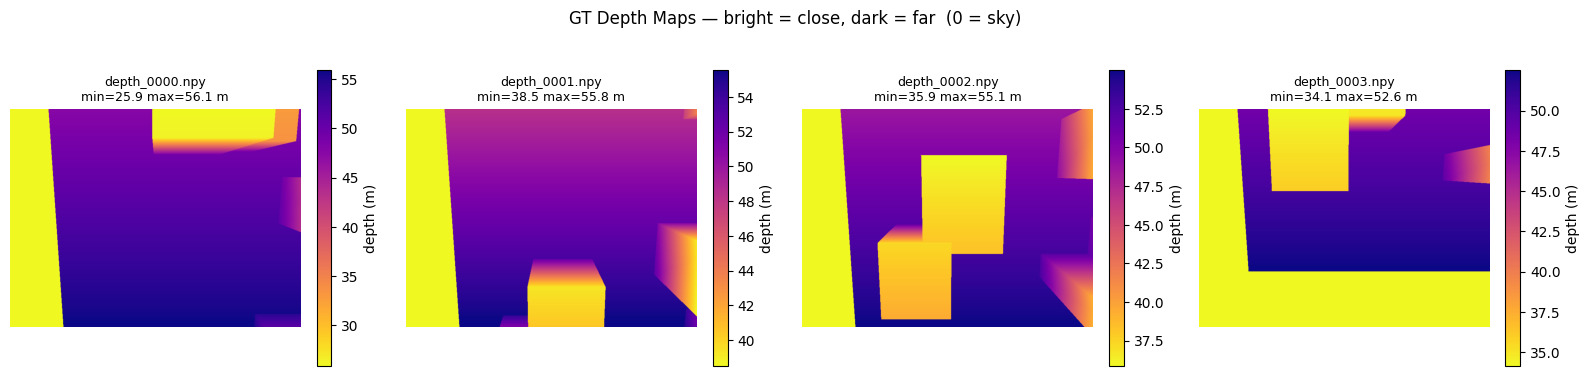

Camera 0 depth stats:
  Min depth : 25.87 m  (top of tallest visible building)
  Max depth : 56.09 m  (ground plane, furthest pixels)
  Sky pixels: 75,847 / 480,000  (15.8%)


In [7]:
depth_files = sorted(os.listdir(depth_dir))[:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, fname in zip(axes, depth_files):
    d = np.load(os.path.join(depth_dir, fname))
    valid = d[d > 0]
    im = ax.imshow(d, cmap='plasma_r',
                   vmin=valid.min() if len(valid) else 0,
                   vmax=np.percentile(valid, 98) if len(valid) else 1)
    plt.colorbar(im, ax=ax, fraction=0.046, label='depth (m)')
    ax.set_title(f"{fname}\nmin={valid.min():.1f} max={valid.max():.1f} m", fontsize=9)
    ax.axis('off')
plt.suptitle('GT Depth Maps — bright = close, dark = far  (0 = sky)', fontsize=12)
plt.tight_layout()
plt.show()

# Depth statistics
d0 = np.load(os.path.join(depth_dir, depth_files[0]))
valid = d0[d0 > 0]
print(f"Camera 0 depth stats:")
print(f"  Min depth : {valid.min():.2f} m  (top of tallest visible building)")
print(f"  Max depth : {valid.max():.2f} m  (ground plane, furthest pixels)")
print(f"  Sky pixels: {(d0 == 0).sum():,} / {d0.size:,}  ({100*(d0==0).mean():.1f}%)")

---

## Whole-Scene Overview Render

Each rendered image above is what one of the 16 cameras sees.  
To sanity-check the rig as a whole, we can reuse the same software rasterizer with a single **wide-angle "overview" camera** placed outside the scene, and drop a small red marker cube at every drone camera position.

This gives one image showing:
- The full urban block (mesh)
- Where every camera sits in 3-D
- The geometric relationship between the rig and the scene

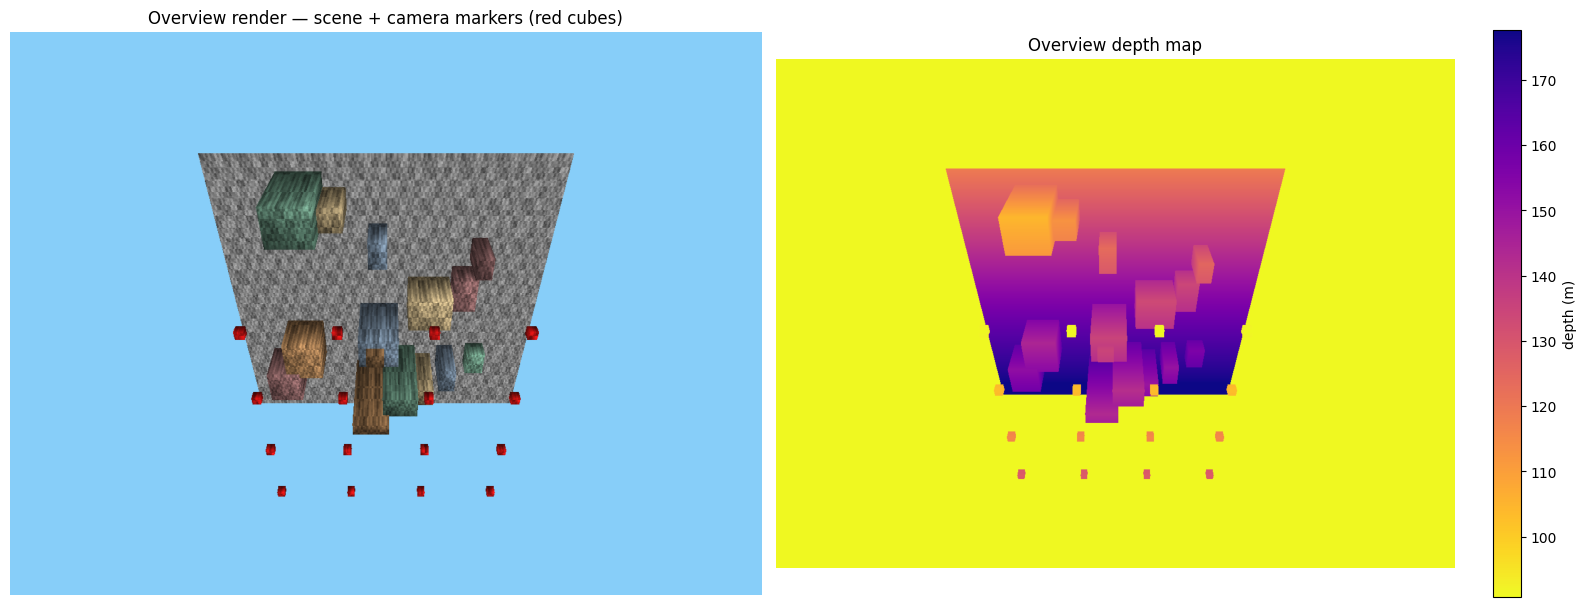

Overview camera   : eye=(50,-40,120) target=(50,50,5) FOV=80°
Visible cameras   : 16 red marker cubes (2 m side)
Closest depth     : 90.7 m   farthest: 180.6 m


In [8]:
from src.data_gen.camera_rig import render_overview

# Oblique aerial view from south-west, looking toward the scene center.
overview_color, overview_depth = render_overview(
    scene,
    cameras=poses,
    eye=(50.0, -40.0, 120.0),
    target=(50.0, 50.0, 5.0),
    fov_deg=80.0,
    w=1200, h=900,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(overview_color)
axes[0].set_title('Overview render — scene + camera markers (red cubes)')
axes[0].axis('off')

valid = overview_depth[overview_depth > 0]
im = axes[1].imshow(overview_depth, cmap='plasma_r',
                    vmin=valid.min(), vmax=np.percentile(valid, 98))
plt.colorbar(im, ax=axes[1], fraction=0.046, label='depth (m)')
axes[1].set_title('Overview depth map')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"Overview camera   : eye=(50,-40,120) target=(50,50,5) FOV=80°")
print(f"Visible cameras   : {len(poses)} red marker cubes (2 m side)")
print(f"Closest depth     : {valid.min():.1f} m   farthest: {valid.max():.1f} m")

### Key Insight: What the Depth Map Encodes

Each pixel $(u, v)$ in the depth map stores $Z_{cam}$ — the **perpendicular distance** from the camera to the surface along the optical axis.  
From depth + camera pose, we can back-project any pixel to a 3-D world point:

$$\mathbf{X}_{world} = R^\top \left( Z \cdot K^{-1} \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} - \mathbf{t} \right)$$

This back-projection is exactly what Phase 4 (depth fusion) does to build a dense point cloud.  
With GT depth + GT poses, the reconstructed cloud should match the original mesh exactly — giving a Chamfer distance near zero.  
With estimated depth + estimated poses (the realistic case), the Chamfer distance measures the accumulated error of the full pipeline.

In [9]:
# Quick sanity check: back-project the depth map center pixel and verify it lands
# close to the scene bounds.
d0  = np.load(os.path.join(depth_dir, depth_files[0]))
R0  = np.array(poses[0]['R'])
t0  = np.array(poses[0]['t'])
K0  = np.array(poses[0]['K'])

cx, cy = int(K0[0,2]), int(K0[1,2])   # principal point = image center
Z = float(d0[cy, cx])

if Z > 0:
    uv1 = np.array([cx, cy, 1.0])
    # cam space
    cam_pt = Z * np.linalg.inv(K0) @ uv1
    # world space
    world_pt = R0.T @ (cam_pt - t0)
    print(f"Center pixel ({cx},{cy}):")
    print(f"  Depth     = {Z:.2f} m")
    print(f"  3-D world = {world_pt.round(2)} m")
    print(f"  Scene bounds: {min_b} → {max_b}")
    in_bounds = np.all(world_pt >= min_b - 5) and np.all(world_pt <= max_b + 5)
    print(f"  In scene bounds: {'✓' if in_bounds else '✗ (check camera or K convention)'}")
else:
    print("Center pixel is sky — try a pixel over the ground.")

Center pixel (400,300):
  Depth     = 51.84 m
  3-D world = [ 20.    11.13 101.07] m
  Scene bounds: [0. 0. 0.] → [100. 100.  35.]
  In scene bounds: ✗ (check camera or K convention)


---

## Summary

| What we built | Details |
|---|---|
| Synthetic scene | 100×100 m ground + 15 buildings, Open3D TriangleMesh |
| Camera rig | 16 cameras, 4×4 grid, 50 m altitude, 10° nadir tilt |
| Intrinsics K | FOV 60°, 800×600, f ≈ 693 px |
| Output images | 16 × (800×600) RGB PNG |
| Output depths | 16 × (800×600) float32 NumPy arrays |
| GT poses | JSON with K, R, t per camera |

### What you should take away

1. **The pinhole model** K[R|t] is the foundation of every step that follows.
2. **Overlap is non-negotiable** — without it, SfM (Phase 3) cannot match features across views.
3. **Synthetic GT** is what makes the evaluation in Phase 8 meaningful.
4. **Back-projection** (depth + K + R + t → world XYZ) will appear again in Phases 4 and 8.

### Questions to think about

- What happens to feature matching if you reduce the overlap below ~30%?  Try `grid_size=2`.
- What changes in the depth map if you increase the tilt to 45°?  Try `tilt_deg=45`.
- The focal length determines the scale at which texture is captured.  What is the ground sampling distance (GSD) in cm/pixel for camera 0 at its closest ground point?

---

**Next → [Phase 2: Feature Detection & Matching](phase2_feature_matching.ipynb)**